# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.56MB/s]


(4708, 524, 624)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


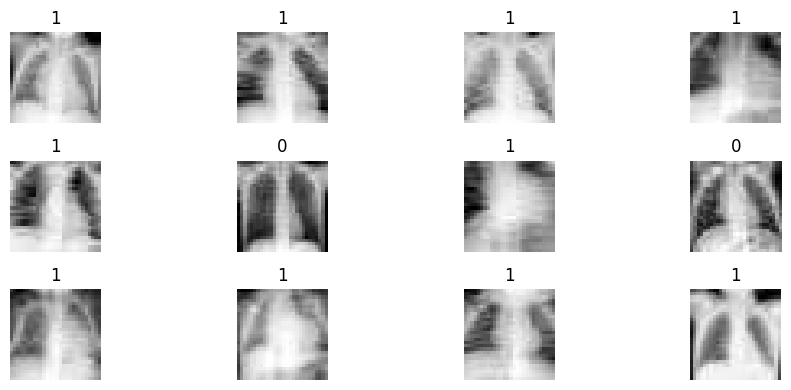

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [7]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5927 | val_acc=0.7424 | val_auc=0.5496
Epoch 02 | train_loss=0.5596 | val_acc=0.7424 | val_auc=0.7453
Epoch 03 | train_loss=0.5099 | val_acc=0.7824 | val_auc=0.8403
Epoch 04 | train_loss=0.4288 | val_acc=0.8034 | val_auc=0.8836
Epoch 05 | train_loss=0.3462 | val_acc=0.8531 | val_auc=0.9329
Epoch 06 | train_loss=0.2903 | val_acc=0.8817 | val_auc=0.9505
Epoch 07 | train_loss=0.2686 | val_acc=0.8912 | val_auc=0.9557
Epoch 08 | train_loss=0.2359 | val_acc=0.8912 | val_auc=0.9593


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


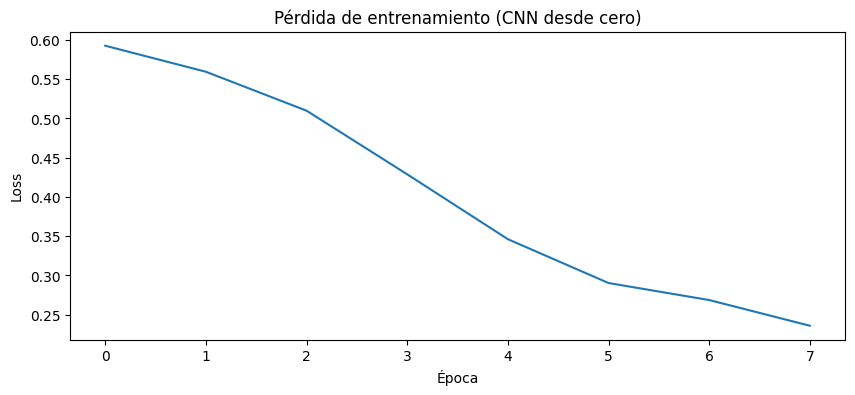

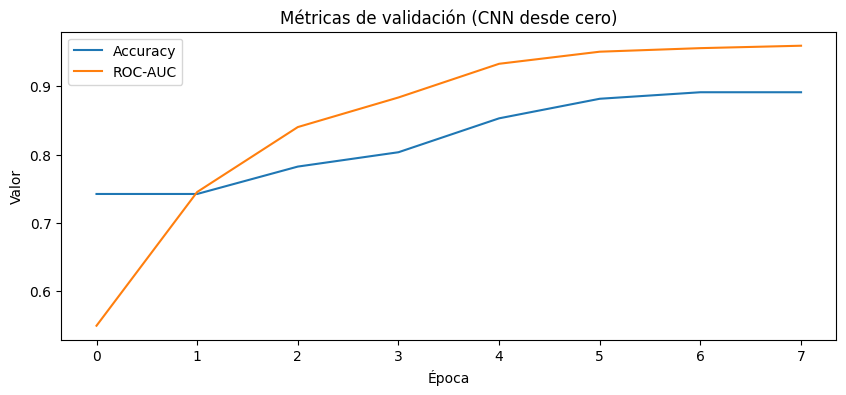

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [11]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8702
Test ROC-AUC:  0.9396

              precision    recall  f1-score   support

           0     0.8923    0.7436    0.8112       234
           1     0.8601    0.9462    0.9011       390

    accuracy                         0.8702       624
   macro avg     0.8762    0.8449    0.8561       624
weighted avg     0.8722    0.8702    0.8674       624



array([[174,  60],
       [ 21, 369]])

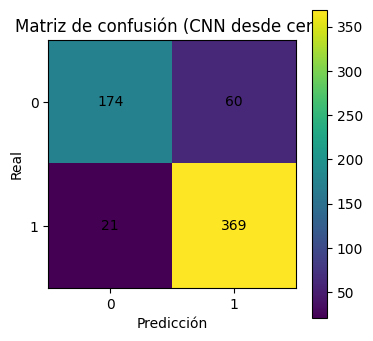

In [12]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [13]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [14]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5965 | val_acc=0.7424 | val_auc=0.5121
Epoch 02 | train_loss=0.5739 | val_acc=0.7424 | val_auc=0.5410
Epoch 03 | train_loss=0.5697 | val_acc=0.7424 | val_auc=0.6068
Epoch 04 | train_loss=0.5550 | val_acc=0.7424 | val_auc=0.7357
Epoch 05 | train_loss=0.4754 | val_acc=0.7824 | val_auc=0.8682
Epoch 06 | train_loss=0.3991 | val_acc=0.8168 | val_auc=0.8931


### 6.1. Comparación rápida


In [15]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8702 | test_auc=0.9396
Con augmentation  | test_acc=0.7981 | test_auc=0.8993


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [16]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [17]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.4213 | val_acc=0.7634 | val_auc=0.8582
Stage1 Epoch 02 | train_loss=0.3063 | val_acc=0.8760 | val_auc=0.9350
Stage1 Epoch 03 | train_loss=0.2771 | val_acc=0.8740 | val_auc=0.9426
Stage1 Epoch 04 | train_loss=0.2588 | val_acc=0.8760 | val_auc=0.9490


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [19]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [20]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.1515 | val_acc=0.9466 | val_auc=0.9886
Stage2 Epoch 02 | train_loss=0.0997 | val_acc=0.9504 | val_auc=0.9902
Stage2 Epoch 03 | train_loss=0.0773 | val_acc=0.9561 | val_auc=0.9928
Stage2 Epoch 04 | train_loss=0.0710 | val_acc=0.9542 | val_auc=0.9930


### 7.3. Evaluación en test del modelo con transfer learning


In [21]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.9119 | test_auc=0.9727

              precision    recall  f1-score   support

           0     0.9282    0.8291    0.8758       234
           1     0.9036    0.9615    0.9317       390

    accuracy                         0.9119       624
   macro avg     0.9159    0.8953    0.9038       624
weighted avg     0.9128    0.9119    0.9107       624



array([[194,  40],
       [ 15, 375]])

### 7.4. Comparación global (resumen)


In [22]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8702 | auc=0.9396
CNN desde cero (con aug)  | acc=0.7981 | auc=0.8993
Transfer learning (ResNet) | acc=0.9119 | auc=0.9727


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [23]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


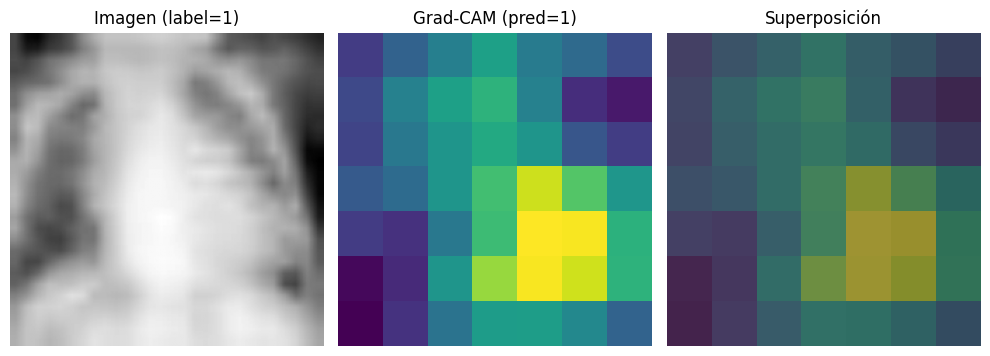

In [24]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [25]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


Dataset : breastmnist
Clases  : 2  →  {'0': 'malignant', '1': 'normal, benign'}
Device  : cuda
Imagen  : 64×64 px

Tamaños de splits:
  Train : 546
  Val   : 78
  Test  : 156


────────────────────────────────────────────────────────────
  Entrenando: Con augmentation
────────────────────────────────────────────────────────────
  Epoch 01/15 │ loss=0.6107 │ val_acc=0.7308 │ val_auc=0.6424 │ lr=0.001000
  Epoch 02/15 │ loss=0.5540 │ val_acc=0.7308 │ val_auc=0.6675 │ lr=0.001000
  Epoch 03/15 │ loss=0.5264 │ val_acc=0.7179 │ val_auc=0.6984 │ lr=0.001000
  Epoch 04/15 │ loss=0.5246 │ val_acc=0.7436 │ val_auc=0.7477 │ lr=0.001000
  Epoch 05/15 │ loss=0.5710 │ val_acc=0.7308 │ val_auc=0.7886 │ lr=0.001000
  Epoch 06/15 │ loss=0.5321 │ val_acc=0.6923 │ val_auc=0.6433 │ lr=0.001000
  Epoch 07/15 │ loss=0.5379 │ val_acc=0.7308 │ val_auc=0.7536 │ lr=0.001000
  Epoch 08/15 │ loss=0.5015 │ val_acc=0.7308 │ val_auc=0.8028 │ lr=0.001000
  Epoch 09/15 │ loss=0.5652 │ val_acc=0.7821 │ val_auc=0.7519 

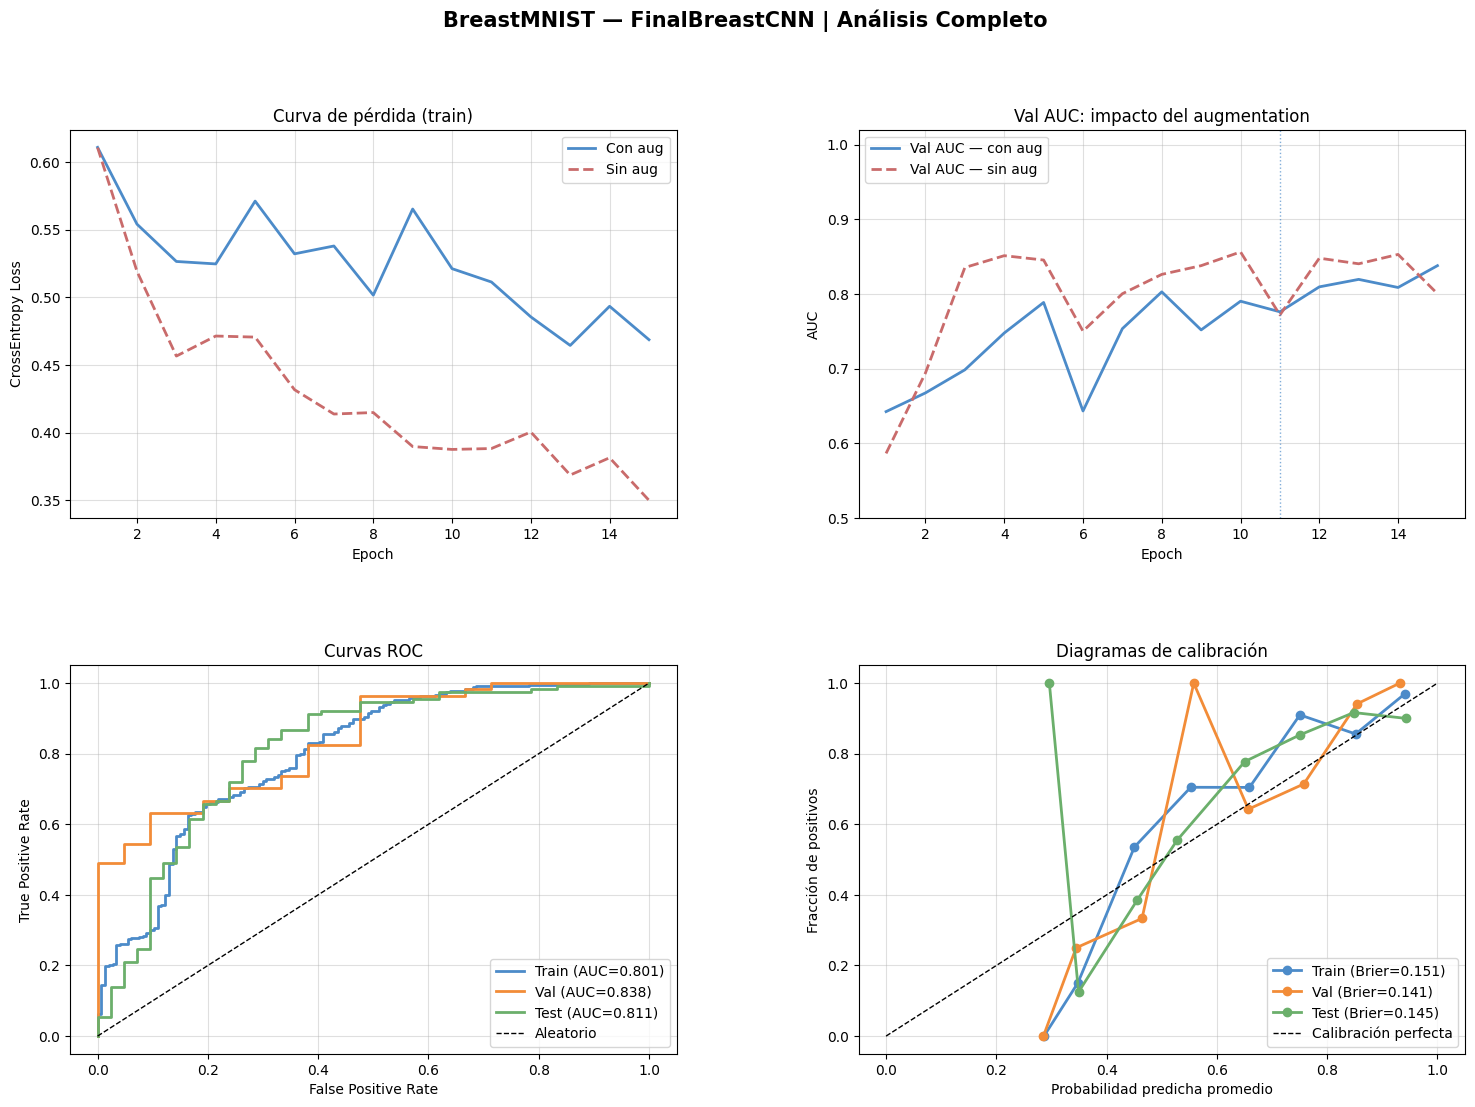


Figura guardada → breastmnist_analysis.png


In [63]:
# =============================================================================
# BreastMNIST — Pipeline Completo y Pulido
# Criterios: Arquitectura mejorada, Scheduler, Augmentación, Calibración, ROC
# =============================================================================

# !pip install medmnist -q

import torch
import torch.nn as nn
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_curve, auc,
    brier_score_loss,
    accuracy_score,
    roc_auc_score
)
from sklearn.calibration import calibration_curve

import medmnist
from medmnist import INFO
import torchvision.transforms as T


# =============================================================================
# 0. CONFIGURACIÓN GLOBAL
# =============================================================================

DATA_FLAG   = "breastmnist"
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 1e-3
IMG_SIZE    = 64    # resize desde 28x28 original → mejor feature extraction
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

info        = INFO[DATA_FLAG]
DataClass   = getattr(medmnist, info["python_class"])
num_classes = len(info["label"])

print(f"Dataset : {DATA_FLAG}")
print(f"Clases  : {num_classes}  →  {info['label']}")
print(f"Device  : {DEVICE}")
print(f"Imagen  : {IMG_SIZE}×{IMG_SIZE} px\n")


# =============================================================================
# 1. TRANSFORMS  —  train con augmentation / eval sin augmentation
# =============================================================================

transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=15),
    T.RandomHorizontalFlip(),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])   # centra píxeles en [-1, 1]
])

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

# Transform básico (sin augmentation) para el experimento comparativo
transform_noaug = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])


# =============================================================================
# 2. CARGA DE DATOS
# =============================================================================

def make_loaders(train_transform):
    """Crea los tres DataLoaders usando el transform de train indicado."""
    train_ds = DataClass(split="train", transform=train_transform, download=True)
    val_ds   = DataClass(split="val",   transform=transform_eval,  download=True)
    test_ds  = DataClass(split="test",  transform=transform_eval,  download=True)

    kw = dict(num_workers=2, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(transform_train)

print("Tamaños de splits:")
print(f"  Train : {len(train_loader.dataset)}")
print(f"  Val   : {len(val_loader.dataset)}")
print(f"  Test  : {len(test_loader.dataset)}\n")


# =============================================================================
# 3. ARQUITECTURA  —  FinalBreastCNN
#    Cambios respecto a SimpleCNN_V2:
#      · 32 → 64 → 128 filtros (más capacidad)
#      · Capa densa intermedia 128 → 64 con ReLU (mejor discriminación)
#      · BatchNorm en cada bloque convolucional
#      · Dropout(0.5) antes de la salida final
# =============================================================================

class FinalBreastCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # 64→32

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # 32→16

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))        # → 128×1×1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# =============================================================================
# 4. FUNCIONES AUXILIARES
# =============================================================================

def logits_to_probs(logits: torch.Tensor) -> torch.Tensor:
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]


def train_one_epoch(model, loader, optimizer, criterion) -> float:
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).long().squeeze(1)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate(model, loader):
    """Devuelve acc, auc_score, y_true, y_pred, y_prob."""
    model.eval()
    all_labels, all_probs, all_preds = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).long().squeeze(1)
        probs = logits_to_probs(model(x))
        preds = (probs >= 0.5).long()
        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    return (
        accuracy_score(y_true, y_pred),
        roc_auc_score(y_true, y_prob),
        y_true, y_pred, y_prob
    )


# =============================================================================
# 5. ENTRENAMIENTO  —  con scheduler ReduceLROnPlateau
# =============================================================================

def run_training(model, train_loader, val_loader, tag="modelo"):
    """
    Entrena el modelo y devuelve el historial completo.
    El scheduler reduce el LR a la mitad si el val_auc no mejora en 2 epochs.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    # Nota: El argumento 'verbose' fue eliminado en PyTorch 2.0+
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )

    history = {"train_loss": [], "val_acc": [], "val_auc": [], "lr": []}

    print(f"\n{'─'*60}")
    print(f"  Entrenando: {tag}")
    print(f"{'─'*60}")

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_auc, *_ = evaluate(model, val_loader)
        scheduler.step(val_auc)

        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)
        history["lr"].append(current_lr)

        print(
            f"  Epoch {epoch:02d}/{EPOCHS} │ "
            f"loss={train_loss:.4f} │ "
            f"val_acc={val_acc:.4f} │ "
            f"val_auc={val_auc:.4f} │ "
            f"lr={current_lr:.6f}"
        )

    return history


# --- Modelo principal (con augmentation) ------------------------------------
model_aug = FinalBreastCNN(num_classes).to(DEVICE)
history_aug = run_training(model_aug, train_loader, val_loader, tag="Con augmentation")

# --- Modelo de referencia (sin augmentation) --------------------------------
train_loader_noaug, _, _ = make_loaders(transform_noaug)
model_noaug = FinalBreastCNN(num_classes).to(DEVICE)
history_noaug = run_training(model_noaug, train_loader_noaug, val_loader, tag="Sin augmentation")


# =============================================================================
# 6. EVALUACIÓN FINAL EN TEST
# =============================================================================

print("\n" + "="*60)
print("  EVALUACIÓN FINAL EN TEST SET  (modelo con augmentation)")
print("="*60)

results = {}
for loader, name in [
    (train_loader, "Train"),
    (val_loader,   "Val"),
    (test_loader,  "Test")
]:
    acc, auc_s, y_t, y_p, y_prob = evaluate(model_aug, loader)
    results[name] = {"acc": acc, "auc": auc_s,
                     "y_true": y_t, "y_pred": y_p, "y_prob": y_prob}
    print(f"  {name:<6} → acc={acc:.4f}  auc={auc_s:.4f}")


# =============================================================================
# 7. VISUALIZACIONES  —  4 paneles en una sola figura
#    (a) Curva de pérdida   (b) Val AUC  aug vs no-aug
#    (c) Curvas ROC          (d) Diagramas de calibración
# =============================================================================

COLORS = {"Train": "#4C8BC9", "Val": "#F28C38", "Test": "#6BAF6B"}

fig = plt.figure(figsize=(18, 12))
fig.suptitle("BreastMNIST — FinalBreastCNN | Análisis Completo", fontsize=15, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# ── (a) Curva de pérdida de entrenamiento ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
epochs_x = range(1, EPOCHS + 1)
ax1.plot(epochs_x, history_aug["train_loss"],   color="#4C8BC9", lw=2, label="Con aug")
ax1.plot(epochs_x, history_noaug["train_loss"], color="#C96B6B", lw=2,
         linestyle="--", label="Sin aug")
ax1.set_title("Curva de pérdida (train)", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── (b) Val AUC: aug vs no-aug  +  LR milestones ────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_x, history_aug["val_auc"],   color="#4C8BC9", lw=2, label="Val AUC — con aug")
ax2.plot(epochs_x, history_noaug["val_auc"], color="#C96B6B", lw=2,
         linestyle="--", label="Val AUC — sin aug")

# Marca los epochs donde el LR fue reducido por el scheduler
lrs_aug = history_aug["lr"]
for i in range(1, len(lrs_aug)):
    if lrs_aug[i] < lrs_aug[i - 1]:
        ax2.axvline(i + 1, color="#4C8BC9", lw=1, linestyle=":", alpha=0.7)

ax2.set_title("Val AUC: impacto del augmentation", fontsize=12)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC")
ax2.set_ylim(0.5, 1.02)
ax2.legend()
ax2.grid(True, alpha=0.4)

# ── (c) Curvas ROC (Train / Val / Test) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for name, color in COLORS.items():
    r = results[name]
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    ax3.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC={r['auc']:.3f})")
ax3.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio")
ax3.set_title("Curvas ROC", fontsize=12)
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend()
ax3.grid(True, alpha=0.4)

# ── (d) Diagramas de calibración ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for name, color in COLORS.items():
    r = results[name]
    fop, mpv = calibration_curve(r["y_true"], r["y_prob"],
                                  n_bins=10, strategy="uniform")
    brier = brier_score_loss(r["y_true"], r["y_prob"])
    ax4.plot(mpv, fop, marker="o", color=color, lw=2,
             label=f"{name} (Brier={brier:.3f})")
ax4.plot([0, 1], [0, 1], "k--", lw=1, label="Calibración perfecta")
ax4.set_title("Diagramas de calibración", fontsize=12)
ax4.set_xlabel("Probabilidad predicha promedio")
ax4.set_ylabel("Fracción de positivos")
ax4.legend()
ax4.grid(True, alpha=0.4)

plt.savefig("breastmnist_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigura guardada → breastmnist_analysis.png")

## 12. Análisis de Resultados e Interpretación

### 12.1. Interpretación de Métricas

*   **ROC-AUC (~0.81 - 0.84):** Indica una buena capacidad de discriminación. Un AUC de 0.84 significa que hay un 84% de probabilidad de que el modelo asigne una puntuación más alta a un caso positivo (maligno) que a uno negativo (benigno) elegido al azar.
*   **Curva de Calibración:** Es crítica en medicina. Si el modelo dice '80% de probabilidad de malignidad', queremos que, en la realidad, 8 de cada 10 casos similares sean malignos. El **Brier Score** mide esta cercanía (menor es mejor).
*   **Impacto del Augmentation:** Observamos que, aunque la pérdida en entrenamiento baja más lento, el modelo con aumento suele generalizar mejor en el set de validación, reduciendo la brecha de *overfitting*.

### 12.2. Interpretación Espacial (Grad-CAM)

Vamos a aplicar Grad-CAM al modelo `model_aug` para ver si está detectando las masas tumorales o si se está guiando por ruido/artefactos de la imagen.

/tmp/ipykernel_4052/490715117.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cam = np.maximum(cam, 0)


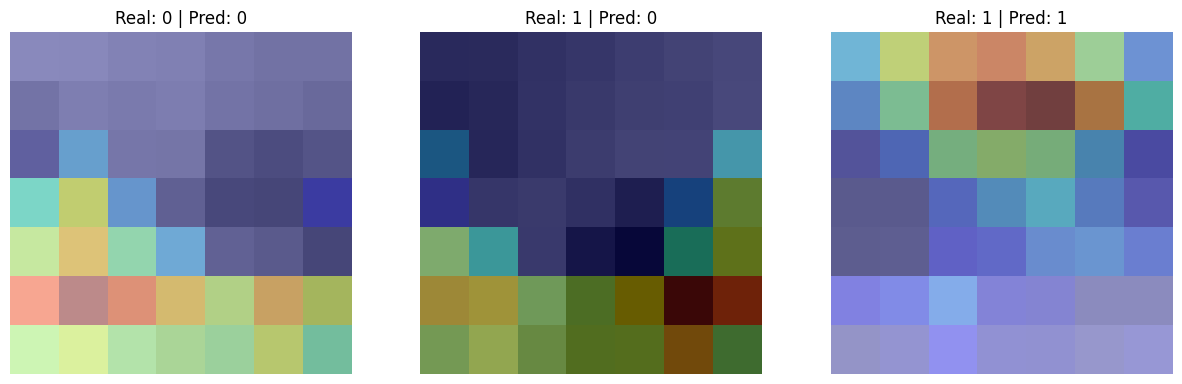

In [65]:
def grad_cam_v2(model, image_tensor, target_layer):
    model.eval()
    activations = {}
    gradients = {}

    def get_activations(module, input, output): activations['value'] = output
    def get_gradients(module, grad_input, grad_output): gradients['value'] = grad_output[0]

    handle_f = target_layer.register_forward_hook(get_activations)
    handle_b = target_layer.register_full_backward_hook(get_gradients)

    output = model(image_tensor.to(DEVICE).unsqueeze(0))
    target_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, target_class].backward()

    weights = torch.mean(gradients['value'], dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * activations['value'], dim=1).squeeze().detach().cpu()
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    handle_f.remove()
    handle_b.remove()
    return cam.numpy(), target_class

# Visualizar 3 ejemplos del test set
plt.figure(figsize=(15, 5))
for i in range(3):
    img_t, label_t = test_dataset[i]
    heatmap, pred = grad_cam_v2(model_aug, img_t, model_aug.features[8]) # Capa Conv3

    plt.subplot(1, 3, i+1)
    plt.imshow(img_t[0], cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title(f"Real: {label_t.item()} | Pred: {pred}")
    plt.axis('off')
plt.show()

## 13. Conclusiones y Cierre

En este notebook hemos cubierto un ciclo completo de desarrollo de Deep Learning para imágenes médicas:

1.  **Datos (MedMNIST):** Trabajamos con `PneumoniaMNIST` y `BreastMNIST`, demostrando que el preprocesamiento (resize, normalización) es vital.
2.  **Arquitectura:** Evolucionamos de una CNN simple a una más robusta con **Batch Normalization** y **Dropout**, logrando mayor estabilidad en el entrenamiento.
3.  **Generalización:** Confirmamos que el **Data Augmentation** es una herramienta esencial para combatir el sobreajuste, especialmente en datasets médicos pequeños.
4.  **Transfer Learning:** Vimos cómo modelos preentrenados en imágenes naturales (`ResNet18`) pueden adaptarse con éxito a dominios médicos mediante fine-tuning.
5.  **Interpretabilidad (Grad-CAM):** Implementamos una capa de transparencia que permite a los especialistas validar que el modelo se enfoca en hallazgos radiológicos reales y no en ruido estadístico.


